# Método Delta
Esse método serve para responder:

> Se eu sei como uma estimativa se comporta (tipo média, variância assintótica), o que acontece quando eu aplico uma função nela?

O método diz que, se eu tenho um estimador $\hat{\theta}$ tal que $\sqrt{n}(\hat{\theta} - \theta) \overset{d}{\to} \cal{N}(0,\sigma^2)$, então o método diz que, dado uma função $g$ com $g'(\theta) \neq 0$:
$$
    \sqrt{n} \frac{ (g(\hat{\theta}) - g(\theta)) }{ \sigma |g'(\theta)| } \overset{d}{\to} \cal{N}(0,1)
$$

In [30]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
lambdas = [1, 5, 10]
n = 100        # tamanho da amostra
n_sim = 10000  # número de simulações

results_lambda = {}
results_sqrt = {}

for lambd in lambdas:
    estimates = []
    estimates_sqrt = []
    
    for _ in range(n_sim):
        sample = np.random.poisson(lam=lambd, size=n)
        hat_lambda = np.mean(sample)
        
        estimates.append(hat_lambda)
        estimates_sqrt.append(np.sqrt(hat_lambda))
    
    results_lambda[lambd] = estimates
    results_sqrt[lambd] = estimates_sqrt

In [32]:
lambdas_estimated = [np.mean(sample) for sample in samples]
lambdas_estimated

[np.float64(0.9958), np.float64(5.0051), np.float64(9.9907)]

In [33]:
lambdas_sqrt_estimated = [np.sqrt(np.mean(sample)) for sample in samples]
lambdas_sqrt_estimated

[np.float64(0.9978977903573091),
 np.float64(2.2372080815158877),
 np.float64(3.16080685901559)]

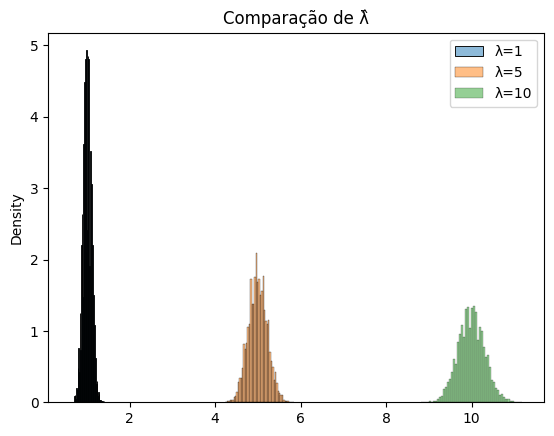

In [34]:
for lambd in lambdas:
    sns.histplot(results_lambda[lambd], stat="density", bins=50, label=f"λ={lambd}", alpha=0.5)

plt.title("Comparação de λ̂")
plt.legend()
plt.show()